# Training Lightweight Outcome + Severity

Notebook ini melatih model ringan untuk dua target akhir:

1. **Keberhasilan** (`success_label`)
2. **Severity** (`severity_percent_poisson3d` dan `severity_label`)

Karena jumlah pasien valid saat ini sangat kecil, training dibuat konservatif:

- Severity: Ridge regression ringan dengan evaluasi Leave-One-Out Cross Validation.
- Success: jika label hanya satu kelas, model supervised tidak bisa dilatih; notebook membuat constant baseline dan memberi warning.
- Beberapa pilihan model ringan dibandingkan otomatis, lalu model terbaik disimpan.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"notebook-process", "notebook-preprocess"} else Path.cwd()
FUSION_PATH = PROJECT_ROOT / "data" / "ecg-data-features" / "fusion-ready" / "fusion_features.csv"
FEATURE_NAMES_PATH = PROJECT_ROOT / "data" / "ecg-data-features" / "fusion-ready" / "fusion_feature_names.csv"
SEVERITY_LABEL_PATH = PROJECT_ROOT / "data" / "severity-labels" / "severity_labels.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "model-training-lightweight"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

SEVERITY_THRESHOLDS = {
    "none_or_minimal": 5.0,
    "mild": 15.0,
    "moderate": 30.0,
}

print(f"Project root : {PROJECT_ROOT}")
print(f"Fusion path  : {FUSION_PATH}")
print(f"Label path   : {SEVERITY_LABEL_PATH}")
print(f"Output dir   : {OUTPUT_DIR}")


Project root : /home/nugee/code-program/code-thesis/thesis-severity
Fusion path  : /home/nugee/code-program/code-thesis/thesis-severity/data/ecg-data-features/fusion-ready/fusion_features.csv
Label path   : /home/nugee/code-program/code-thesis/thesis-severity/data/severity-labels/severity_labels.csv
Output dir   : /home/nugee/code-program/code-thesis/thesis-severity/data/model-training-lightweight


## 1. Load dataset fusion dan label

Input utama berasal dari:

- `fusion_features.csv`: fitur klinis + top-5 PVC confidence + embedding PVC ViT.
- `severity_labels.csv`: label success dan severity dari mapping.


In [2]:
fusion = pd.read_csv(FUSION_PATH)
labels = pd.read_csv(SEVERITY_LABEL_PATH)

metadata_columns = {"patient_id", "selected_pvc_count", "fusion_vector_dim"}
feature_columns = [column for column in fusion.columns if column not in metadata_columns]

dataset = fusion.merge(
    labels[["patient_id", "success_label", "severity_percent_poisson3d", "severity_label"]],
    on="patient_id",
    how="inner",
)

print(f"Dataset shape      : {dataset.shape}")
print(f"Feature count      : {len(feature_columns)}")
print(f"Patient count      : {dataset['patient_id'].nunique()}")
print(f"Success classes    : {sorted(dataset['success_label'].dropna().unique().tolist())}")
print(f"Severity labels    : {dataset['severity_label'].tolist()}")

dataset[["patient_id", "selected_pvc_count", "success_label", "severity_percent_poisson3d", "severity_label"]]


Dataset shape      : (4, 3863)
Feature count      : 3857
Patient count      : 4
Success classes    : [1]
Severity labels    : ['moderate', 'mild', 'severe', 'none_or_minimal']


,patient_id,selected_pvc_count,success_label,severity_percent_poisson3d,severity_label
0,P-00001,4,1,24.594766,moderate
1,P-00002,3,1,6.580066,mild
2,P-00007,5,1,37.909025,severe
3,P-00015,0,1,3.812190,none_or_minimal


## 2. Pilihan model ringan

Pilihan yang cocok untuk kondisi data saat ini:

- **Compact Ridge Regression**: direkomendasikan sekarang. Memakai fitur klinis + confidence PVC saja, tanpa ribuan dimensi embedding.
- **Fusion Top-K Ridge Regression**: memakai semua fitur fusion, tetapi memilih top-k fitur berdasarkan korelasi pada train fold.
- **Tiny MLP**: cocok nanti saat pasien jauh lebih banyak; tidak direkomendasikan untuk 4 pasien karena sangat mudah overfit.

Notebook ini melatih dan membandingkan dua model Ridge. Tiny MLP disediakan sebagai opsi metodologis, bukan default training.


In [3]:
def severity_label_from_percent(percent: float) -> str:
    if percent < SEVERITY_THRESHOLDS["none_or_minimal"]:
        return "none_or_minimal"
    if percent < SEVERITY_THRESHOLDS["mild"]:
        return "mild"
    if percent < SEVERITY_THRESHOLDS["moderate"]:
        return "moderate"
    return "severe"


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def standardize_train_test(x_train: np.ndarray, x_test: np.ndarray):
    mean = x_train.mean(axis=0)
    std = x_train.std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    return (x_train - mean) / std, (x_test - mean) / std, mean, std


def topk_by_train_correlation(x_train: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    if k is None or k >= x_train.shape[1]:
        return np.arange(x_train.shape[1])
    y_centered = y_train - y_train.mean()
    x_centered = x_train - x_train.mean(axis=0)
    numerator = np.abs(np.sum(x_centered * y_centered[:, None], axis=0))
    denominator = np.sqrt(np.sum(x_centered ** 2, axis=0) * np.sum(y_centered ** 2)) + 1e-8
    scores = numerator / denominator
    return np.argsort(scores)[-k:]


def fit_ridge(x: np.ndarray, y: np.ndarray, alpha: float) -> np.ndarray:
    x_aug = np.column_stack([np.ones(len(x)), x])
    penalty = np.eye(x_aug.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(x_aug.T @ x_aug + alpha * penalty, x_aug.T @ y)


def predict_ridge(x: np.ndarray, weights: np.ndarray) -> np.ndarray:
    x_aug = np.column_stack([np.ones(len(x)), x])
    return x_aug @ weights


def leave_one_out_ridge(data: pd.DataFrame, columns: list[str], alpha: float, top_k: int | None = None) -> pd.DataFrame:
    patient_ids = data["patient_id"].to_numpy()
    x_all = data[columns].to_numpy(dtype=np.float32)
    y_all = data["severity_percent_poisson3d"].to_numpy(dtype=np.float32)
    rows = []

    for test_idx in range(len(data)):
        train_idx = np.array([idx for idx in range(len(data)) if idx != test_idx])
        x_train_raw = x_all[train_idx]
        x_test_raw = x_all[[test_idx]]
        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        x_train, x_test, _, _ = standardize_train_test(x_train_raw, x_test_raw)
        selected_idx = topk_by_train_correlation(x_train, y_train, top_k) if top_k is not None else np.arange(x_train.shape[1])
        x_train_sel = x_train[:, selected_idx]
        x_test_sel = x_test[:, selected_idx]

        weights = fit_ridge(x_train_sel, y_train, alpha=alpha)
        pred = float(predict_ridge(x_test_sel, weights)[0])
        pred = float(np.clip(pred, 0.0, 100.0))
        rows.append({
            "patient_id": patient_ids[test_idx],
            "actual_severity_percent": float(y_test),
            "predicted_severity_percent": pred,
            "actual_severity_label": severity_label_from_percent(float(y_test)),
            "predicted_severity_label": severity_label_from_percent(pred),
            "alpha": alpha,
            "top_k": top_k if top_k is not None else len(columns),
            "selected_feature_count": int(len(selected_idx)),
        })
    return pd.DataFrame(rows)


clinical_columns = [c for c in feature_columns if c in {
    "risk_hipertensi", "risk_diabetes", "risk_cad", "syncope", "coronary_catheterization",
    "lvef", "lvidd", "tapse", "rv_dilatation", "diastolic_function_grade",
    "holter_pvc_percent", "run_vt",
}]
confidence_columns = [c for c in feature_columns if c.startswith("pvc_conf_top_")]
compact_columns = clinical_columns + confidence_columns

model_options = []
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model_options.append({"model_name": "compact_ridge", "columns": compact_columns, "alpha": alpha, "top_k": None})
for alpha in [0.1, 1.0, 10.0, 100.0]:
    for top_k in [4, 8, 16, 32]:
        model_options.append({"model_name": "fusion_topk_ridge", "columns": feature_columns, "alpha": alpha, "top_k": top_k})

print(f"Compact feature count: {len(compact_columns)}")
print(f"Full fusion count    : {len(feature_columns)}")


Compact feature count: 17
Full fusion count    : 3857


## 3. Evaluasi Leave-One-Out CV untuk severity

Dengan 4 pasien, evaluasi terbaik yang masih masuk akal adalah Leave-One-Out. Angka ini tetap harus dibaca sebagai sanity check, bukan performa final publikasi.


In [4]:
evaluation_rows = []
loocv_predictions = []

for option in model_options:
    pred_df = leave_one_out_ridge(
        dataset,
        columns=option["columns"],
        alpha=option["alpha"],
        top_k=option["top_k"],
    )
    y_true = pred_df["actual_severity_percent"].to_numpy()
    y_pred = pred_df["predicted_severity_percent"].to_numpy()
    label_acc = float((pred_df["actual_severity_label"] == pred_df["predicted_severity_label"]).mean())
    evaluation_rows.append({
        "model_name": option["model_name"],
        "feature_count": len(option["columns"]),
        "alpha": option["alpha"],
        "top_k": option["top_k"] if option["top_k"] is not None else len(option["columns"]),
        "mae": mae(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "severity_label_accuracy": label_acc,
    })
    pred_df.insert(0, "model_name", option["model_name"])
    loocv_predictions.append(pred_df)

model_evaluation = pd.DataFrame(evaluation_rows).sort_values(["mae", "rmse"]).reset_index(drop=True)
loocv_predictions = pd.concat(loocv_predictions, ignore_index=True)

model_evaluation.to_csv(OUTPUT_DIR / "severity_model_options_loocv.csv", index=False)
loocv_predictions.to_csv(OUTPUT_DIR / "severity_loocv_predictions_all_options.csv", index=False)

best_option_row = model_evaluation.iloc[0]
best_option = next(
    option for option in model_options
    if option["model_name"] == best_option_row["model_name"]
    and float(option["alpha"]) == float(best_option_row["alpha"])
    and int(option["top_k"] if option["top_k"] is not None else len(option["columns"])) == int(best_option_row["top_k"])
)

print("Best option:")
print(best_option_row.to_string())
model_evaluation


Best option:
model_name                 fusion_topk_ridge
feature_count                           3857
alpha                                    0.1
top_k                                      8
mae                                 8.752155
rmse                               10.671868
severity_label_accuracy                 0.75


,model_name,feature_count,alpha,top_k,mae,rmse,severity_label_accuracy
0,fusion_topk_ridge,3857,0.10,8,8.752155,10.671868,0.75
1,fusion_topk_ridge,3857,1.00,8,8.876042,10.849859,0.50
2,fusion_topk_ridge,3857,0.10,16,9.505921,13.949318,0.75
3,fusion_topk_ridge,3857,10.00,8,10.131374,11.803785,0.50
4,compact_ridge,17,0.01,17,10.701419,12.115507,0.50
5,compact_ridge,17,0.10,17,10.725972,12.150283,0.50
6,fusion_topk_ridge,3857,1.00,4,10.882066,11.701986,0.25
7,fusion_topk_ridge,3857,0.10,4,10.939775,11.790355,0.25
8,compact_ridge,17,1.00,17,10.947275,12.463569,0.50
9,fusion_topk_ridge,3857,1.00,16,10.965263,14.502838,0.50


## 4. Train final severity model pada semua data

Model terbaik dari LOOCV dilatih ulang pada semua pasien valid dan disimpan sebagai `.npz` agar bisa dipakai inference berikutnya.


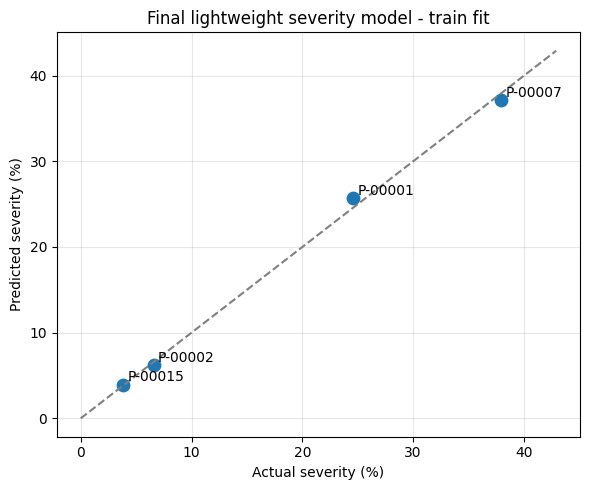

,patient_id,severity_percent_poisson3d,severity_label,success_label,predicted_severity_percent,predicted_severity_label,absolute_error
0,P-00001,24.594766,moderate,1,25.677795,moderate,1.083030
1,P-00002,6.580066,mild,1,6.202259,mild,0.377806
2,P-00007,37.909025,severe,1,37.107298,severe,0.801727
3,P-00015,3.812190,none_or_minimal,1,3.908691,none_or_minimal,0.096501


In [5]:
def fit_final_ridge_model(data: pd.DataFrame, option: dict[str, Any]) -> dict[str, Any]:
    columns = option["columns"]
    x_raw = data[columns].to_numpy(dtype=np.float32)
    y = data["severity_percent_poisson3d"].to_numpy(dtype=np.float32)
    mean = x_raw.mean(axis=0)
    std = x_raw.std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    x = (x_raw - mean) / std
    selected_idx = topk_by_train_correlation(x, y, option["top_k"]) if option["top_k"] is not None else np.arange(x.shape[1])
    weights = fit_ridge(x[:, selected_idx], y, alpha=option["alpha"])
    train_pred = np.clip(predict_ridge(x[:, selected_idx], weights), 0.0, 100.0)
    return {
        "columns": columns,
        "mean": mean,
        "std": std,
        "selected_idx": selected_idx,
        "selected_columns": [columns[idx] for idx in selected_idx],
        "weights": weights,
        "train_pred": train_pred,
    }


final_model = fit_final_ridge_model(dataset, best_option)
train_predictions = dataset[["patient_id", "severity_percent_poisson3d", "severity_label", "success_label"]].copy()
train_predictions["predicted_severity_percent"] = final_model["train_pred"]
train_predictions["predicted_severity_label"] = train_predictions["predicted_severity_percent"].apply(severity_label_from_percent)
train_predictions["absolute_error"] = (train_predictions["severity_percent_poisson3d"] - train_predictions["predicted_severity_percent"]).abs()

np.savez(
    OUTPUT_DIR / "final_lightweight_severity_ridge_model.npz",
    weights=final_model["weights"],
    mean=final_model["mean"],
    std=final_model["std"],
    selected_idx=final_model["selected_idx"],
    selected_columns=np.array(final_model["selected_columns"], dtype=object),
    all_columns=np.array(final_model["columns"], dtype=object),
    alpha=float(best_option["alpha"]),
    model_name=best_option["model_name"],
    top_k=int(best_option["top_k"] if best_option["top_k"] is not None else len(best_option["columns"])),
)

train_predictions.to_csv(OUTPUT_DIR / "severity_train_predictions_final_model.csv", index=False)

plt.figure(figsize=(6, 5))
plt.scatter(train_predictions["severity_percent_poisson3d"], train_predictions["predicted_severity_percent"], s=80)
limit = max(train_predictions["severity_percent_poisson3d"].max(), train_predictions["predicted_severity_percent"].max()) + 5
plt.plot([0, limit], [0, limit], linestyle="--", color="gray")
for _, row in train_predictions.iterrows():
    plt.text(row["severity_percent_poisson3d"] + 0.4, row["predicted_severity_percent"] + 0.4, row["patient_id"])
plt.xlabel("Actual severity (%)")
plt.ylabel("Predicted severity (%)")
plt.title("Final lightweight severity model - train fit")
plt.grid(alpha=0.3)
plt.tight_layout()
plot_path = OUTPUT_DIR / "severity_train_fit_actual_vs_predicted.png"
plt.savefig(plot_path, dpi=160)
plt.show()

train_predictions


## 5. Model keberhasilan

Jika `success_label` hanya punya satu kelas, supervised classifier tidak bisa dilatih. Notebook ini menyimpan constant baseline. Nanti jika ada pasien gagal/kelas 0, model yang cocok adalah Logistic Regression/Ridge Classifier pada fitur compact atau fusion top-k.


In [6]:
success_classes = sorted(dataset["success_label"].dropna().astype(int).unique().tolist())
if len(success_classes) < 2:
    constant_success = int(success_classes[0]) if success_classes else 0
    success_summary = {
        "model_name": "constant_success_baseline",
        "reason": "success_label_has_only_one_class; supervised classifier cannot be trained yet",
        "observed_classes": success_classes,
        "constant_prediction": constant_success,
        "recommended_when_two_classes_available": [
            "compact_logistic_regression",
            "compact_ridge_classifier",
            "fusion_topk_logistic_regression",
        ],
    }
    success_predictions = dataset[["patient_id", "success_label"]].copy()
    success_predictions["predicted_success_label"] = constant_success
    success_predictions["predicted_success_probability"] = float(constant_success)
else:
    # Placeholder branch untuk dataset yang sudah punya kelas berhasil dan gagal.
    success_summary = {
        "model_name": "compact_ridge_classifier_candidate",
        "reason": "two classes available; implement logistic/ridge classifier when data size is sufficient",
        "observed_classes": success_classes,
    }
    success_predictions = dataset[["patient_id", "success_label"]].copy()
    success_predictions["predicted_success_label"] = dataset["success_label"].astype(int)
    success_predictions["predicted_success_probability"] = dataset["success_label"].astype(float)

success_predictions.to_csv(OUTPUT_DIR / "success_predictions_baseline.csv", index=False)
(OUTPUT_DIR / "success_model_summary.json").write_text(json.dumps(success_summary, indent=2))

print(json.dumps(success_summary, indent=2))
success_predictions


{
  "model_name": "constant_success_baseline",
  "reason": "success_label_has_only_one_class; supervised classifier cannot be trained yet",
  "observed_classes": [
    1
  ],
  "constant_prediction": 1,
  "recommended_when_two_classes_available": [
    "compact_logistic_regression",
    "compact_ridge_classifier",
    "fusion_topk_logistic_regression"
  ]
}


,patient_id,success_label,predicted_success_label,predicted_success_probability
0,P-00001,1,1,1.0
1,P-00002,1,1,1.0
2,P-00007,1,1,1.0
3,P-00015,1,1,1.0


## 6. Simpan ringkasan rekomendasi model

Ringkasan ini menjelaskan pilihan model yang paling cocok untuk tahap sekarang dan opsi berikutnya saat jumlah pasien bertambah.


In [7]:
recommendations = [
    {
        "rank": 1,
        "model": "Compact Ridge Regression",
        "target": "severity_percent_poisson3d",
        "status": "recommended_now",
        "why": "Dataset sangat kecil; fitur compact mengurangi risiko overfit dibanding embedding ribuan dimensi.",
    },
    {
        "rank": 2,
        "model": "Fusion Top-K Ridge Regression",
        "target": "severity_percent_poisson3d",
        "status": "candidate_now",
        "why": "Masih ringan, bisa memakai sinyal dari embedding/PVC tetapi hanya top-k fitur paling informatif pada train fold.",
    },
    {
        "rank": 3,
        "model": "Logistic Regression / Ridge Classifier",
        "target": "success_label",
        "status": "use_after_two_classes_exist",
        "why": "Saat ini semua success_label bernilai 1, sehingga classifier supervised belum valid.",
    },
    {
        "rank": 4,
        "model": "Tiny MLP multi-task",
        "target": "success + severity",
        "status": "later_when_more_patients",
        "why": "Bisa multi-output, tetapi membutuhkan data lebih banyak agar tidak menghafal 4 pasien.",
    },
]

training_summary = {
    "patient_count": int(len(dataset)),
    "feature_count": int(len(feature_columns)),
    "success_classes": success_classes,
    "best_severity_option": best_option_row.to_dict(),
    "final_model_path": str(OUTPUT_DIR / "final_lightweight_severity_ridge_model.npz"),
    "success_model_summary_path": str(OUTPUT_DIR / "success_model_summary.json"),
    "recommendations": recommendations,
}

pd.DataFrame(recommendations).to_csv(OUTPUT_DIR / "lightweight_model_recommendations.csv", index=False)
(OUTPUT_DIR / "training_summary.json").write_text(json.dumps(training_summary, indent=2))

print(json.dumps(training_summary, indent=2))
print("\nOutput files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path)

{
  "patient_count": 4,
  "feature_count": 3857,
  "success_classes": [
    1
  ],
  "best_severity_option": {
    "model_name": "fusion_topk_ridge",
    "feature_count": 3857,
    "alpha": 0.1,
    "top_k": 8,
    "mae": 8.75215546032818,
    "rmse": 10.67186817040245,
    "severity_label_accuracy": 0.75
  },
  "final_model_path": "/home/nugee/code-program/code-thesis/thesis-severity/data/model-training-lightweight/final_lightweight_severity_ridge_model.npz",
  "success_model_summary_path": "/home/nugee/code-program/code-thesis/thesis-severity/data/model-training-lightweight/success_model_summary.json",
  "recommendations": [
    {
      "rank": 1,
      "model": "Compact Ridge Regression",
      "target": "severity_percent_poisson3d",
      "status": "recommended_now",
      "why": "Dataset sangat kecil; fitur compact mengurangi risiko overfit dibanding embedding ribuan dimensi."
    },
    {
      "rank": 2,
      "model": "Fusion Top-K Ridge Regression",
      "target": "severity_p